> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib scipy


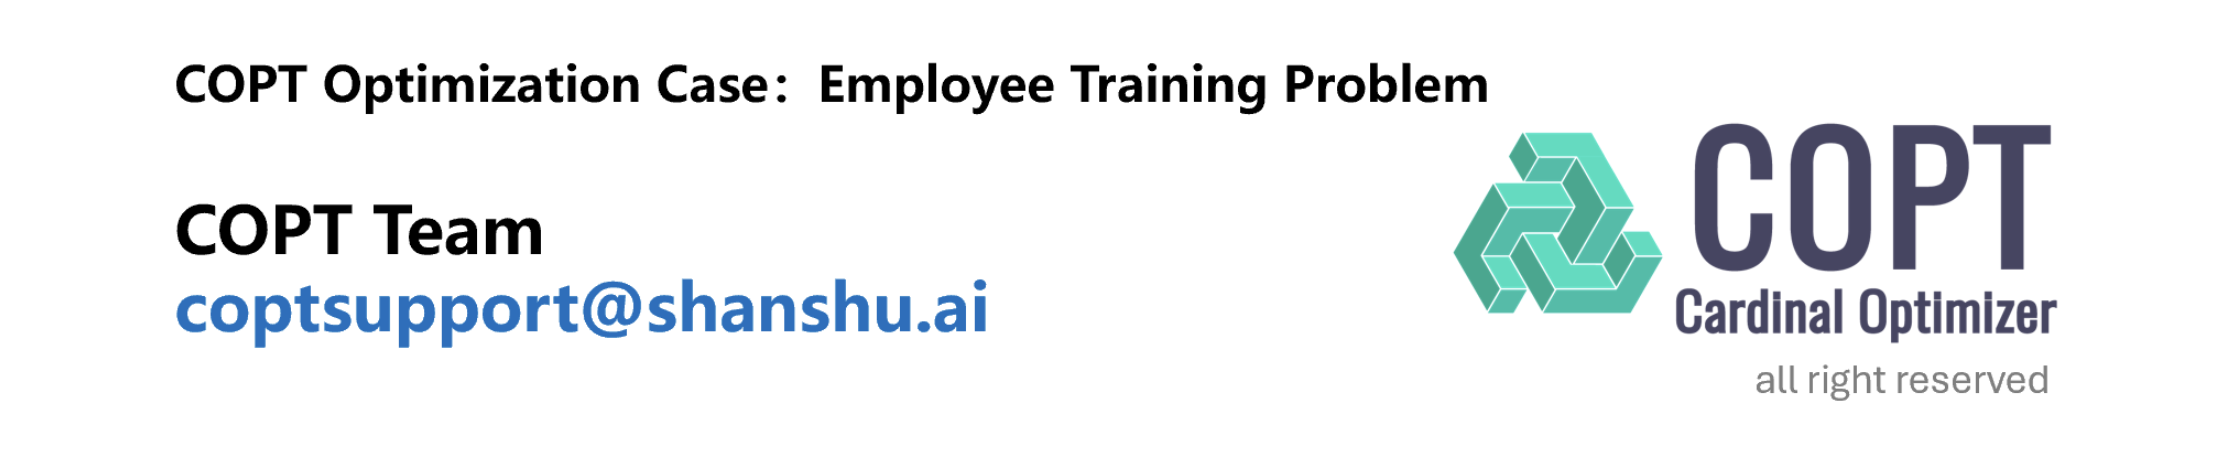

# Employee Training Problem Code Implementation

## Steps to Model and Solve Employee Training Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add Model Data**
    - Organize model parameters, including $c,d,u,v,m$ and sequence data $r_t,l_t$.
    - Clarify the time index set $T=\{1,2,3,4,5,6\}$, and prepare historical initial values (for handling intertemporal terms such as $y_{t-1},y_{t-2}$).

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - For each $t\in T$, create integer variable $x_t$, representing the number of available formal flight attendants in month $t$.
        - For each $t\in T$, create integer variable $y_t$, representing the number of newly recruited interns in month $t$, and set the upper bound to $m$.
    - **Set Objective Function**：Minimize total personnel employment costs, which is a linear objective.
    - **Add Constraints**：
        - The number of flight attendants conforms to the change pattern
        - Total available service hours are not less than the monthly demand hours

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

from scipy.stats import norm
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

## Add Model Data

In [6]:
#  Monthly cost per formal flight attendant
c = 5100
# Monthly cost per intern
d = 3600
# Maximum working hours per month for a flight attendant
u = 150
# Maximum working hours per month for an intern
v = 25
# Maximum number of interns that can be recruited per month
m = 6
# Required flight hours of each month
r = [8000, 9000, 9800, 9900, 10050, 10500]
# Number of flight attendants resigning of each month
l = [2, 0, 2, 0, 1, 0]
# Current planning time period
T = range(1, 7)          # 1..6
X = range(0, 7)      # 0..6
Y = range(-1, 7)      # -1..6

## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model_1 = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
- $x_t \geq 0$: Number of available flight attendants in month $t$ (persons)
- $0 \leq y_t \leq m$: Number of newly hired interns in month $t$ (persons)

In this model, months within the planning period adopt an indexing method starting from 1, where $t=1$ represents the first month of the planning period.

Simultaneously, variables with subscript 0 and negative subscripts are allowed to represent historical states before the planning period begins. Specifically, $x_0$ represents the number of available formal flight attendants before the planning period begins, $y_0$ and $y_{-1}$ represent the number of newly recruited interns one month and two months before the planning period begins, respectively.

In [10]:
x = model_1.addVars(X, vtype=COPT.INTEGER, nameprefix='x')
y = model_1.addVars(Y, vtype=COPT.INTEGER, nameprefix='y')

# Handling of Initial Conditions

In this multi-period personnel planning model, some historical states are known before the planning begins. To avoid introducing unnecessary equality constraints and make the model structure more concise, these known initial states are directly fixed by setting variable bounds, rather than adding additional constraint conditions.

Specifically, it is assumed that historical states before the planning begins are known: in November of last year, 2 new interns were hired, in December of last year, no new interns were added, and at the end of December last year, there were a total of 60 formal flight attendants on duty. In COPT code implementation, the above initial conditions can be characterized by setting the lower and upper bound information of corresponding variables, for example:

In [12]:
x[0].lb = 60
x[0].ub = 60

y[-1].lb = 2
y[-1].ub = 2

y[0].lb = 0
y[0].ub = 0

Through this approach, the model consistently maintains these variable values unchanged during the solving process, thereby naturally integrating known historical states into the multi-period decision-making model. This handling method not only reduces the number of explicit constraints in the model but also helps improve the model's readability and solving efficiency, representing a relatively common engineering implementation method in multi-period planning problems.

### Set Objective Function
$$
    \min \sum_{t = 1} ^ 6 c \cdot x_t + d \cdot (y_t + y_{t-1})
$$

In [15]:
model_1.setObjective(
    cp.quicksum(c * x[t] + d * (y[t] + y[t-1]) for t in T),
    COPT.MINIMIZE
)

### Add Constraints

1. The number of flight attendants each month follows a change pattern (corresponding to the flow conservation law in inventory management)

Based on the above conventions, the dynamic balance relationship of flight attendant numbers can be described in the following two cases:

For the first month of the planning period ($t=1$):

$$x_1 = x_0 + y_{-1}$$

For the remaining months within the planning period ($t=2,\dots,6$):

$$x_t = x_{t-1} - l_{t-1} + y_{t-2}, \quad t = 2,\dots,6$$
The above constraints are used to characterize the evolution process of flight attendant scale between adjacent months, reflecting the dynamic impacts brought by flight attendant resignations and interns completing training and becoming formal flight attendants. They represent typical balance constraint forms in personnel planning problems.


In [18]:
model_1.addConstr(x[1] == x[0] + y[-1])
model_1.addConstrs(
    x[t] == x[t - 1] - l[t - 2] + y[t - 2]
    for t in T if t >= 2
)

2. Flight hour demand (corresponding to prohibition of stockouts in inventory management)
$$
    u * x_t + v * (y_t + y_{t - 1}) \geq r_t, \quad \forall t
$$

In [20]:
model_1.addConstrs(u * x[t] + v * (y[t] + y[t - 1]) >= r[t-1] for t in T)

3. Monthly recruitment limit for interns (corresponding to limited procurement quantity in inventory management)
$$
    y_t \leq m, \quad \forall t
$$

In [22]:
model_1.addConstrs(y[t] <= m for t in T)

## Solve

In [24]:
model_1.solve()

Model fingerprint: cb0e4a9b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    18 rows, 15 columns and 42 non-zero elements
    15 integers

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    5 rows, 6 columns and 17 non-zero elements
    6 integers

Problem info:
    Range of matrix coefficients:    [1e+00,2e+02]
    Range of rhs coefficients:       [4e+00,1e+04]
    Range of bound coefficients:     [6e+00,7e+01]
    Range of cost coefficients:      [4e+03,2e+04]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  1.965900e+06            --     Inf  0.05s
H        0         1      --       0  1.96

## Retrieve Results

Optimal total cost: 2077500.000000

Monthly trainee hiring plan and available flight attendants:


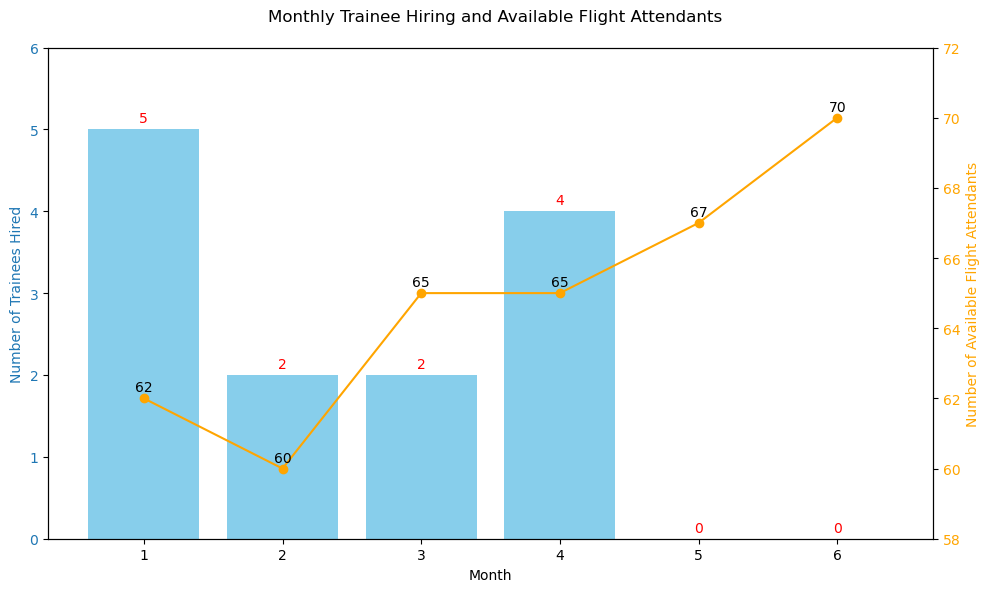

In [26]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

if model_1.status == COPT.OPTIMAL:
    print(f'Optimal total cost: {model_1.objVal:0f}')
    print('\nMonthly trainee hiring plan and available flight attendants:')

    months = list(range(1,7))

    trainees = [int(y[t].x) for t in months]
    trainers = [int(x[t].x) for t in months]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart: trainees (left axis)
    ax1.bar(months, trainees, color='skyblue')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Number of Trainees Hired', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, max(trainees) + 1)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotate bar values (trainees)
    for x_pos, val in zip(months, trainees):
        ax1.annotate(
            f'{val}',
            xy=(x_pos, val),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            color='red',
            fontsize=10
        )

    # Line chart: flight attendants (right axis)
    ax2 = ax1.twinx()
    ax2.plot(months, trainers, color='orange', marker='o')
    ax2.set_ylabel('Number of Available Flight Attendants', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2_min = min(trainers)
    ax2_max = max(trainers)
    ax2.set_ylim(ax2_min - 2, ax2_max + 2)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotate line points
    for mon, val in zip(months, trainers):
        ax2.annotate(
            f'{val}',
            xy=(mon, val),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            fontsize=10
        )

    fig.suptitle('Monthly Trainee Hiring and Available Flight Attendants')
    plt.tight_layout()
    plt.show()
else:
    print('Optimal solution not found')


# Case Expansion: Employee Training Problem with Randomness

In the stochastic extension model, the overall modeling framework remains consistent with the deterministic model, with the main difference lying in the construction method of input parameters. Unlike treating demands and personnel turnover as fixed values, in this extension problem, related parameters are regarded as random variables with statistical characteristics, thereby explicitly characterizing uncertainty factors in the operational environment within the model.

## Construction and Processing of Model Data

At the code implementation level, the stochastic extension model no longer directly uses given demand values and resignation numbers but estimates their statistical characteristics based on historical data, assuming they follow normal distributions. Specifically, historical samples are first used to calculate the mean and variance of monthly flight working hour demands and flight attendant resignation numbers. Under the given confidence level $1-\alpha$, by calculating corresponding quantiles, random variables are transformed into deterministic equivalent parameters. The resulting quantile values serve as model inputs, used to replace $r_t$ and $l_t$ in the original deterministic model, thereby constructing an optimization model that satisfies operational demands and personnel balance requirements in a probabilistic sense.

This processing approach enables the model to introduce a risk control mechanism for uncertainty while maintaining the integer programming structure unchanged. By adjusting parameter $\alpha$, it can flexibly reflect managers' risk tolerance levels, achieving reasonable trade-offs between cost control and service assurance, and also providing an operational engineering implementation path for personnel recruitment and training decisions in stochastic environments.

In [28]:
# Historical statistics (mean and variance)
r_mean = [8266, 8895, 9273, 9217, 9693, 10052]
r_var  = [1215, 1466, 1876, 1653, 1996, 2157]

l_mean = [1.15, 0.80, 1.30, 1.45, 0.85, 1.40]
l_var  = [0.57, 0.58, 0.73, 0.75, 0.50, 0.79]

# Risk level (confidence level = 1 - alpha)
alpha = 0.05
z_value = norm.ppf(1 - alpha)

# Quantile-based deterministic equivalents
r_hat = [
    r_mean[t] + z_value * math.sqrt(r_var[t])
    for t in range(6)
]

l_hat = [
    l_mean[t] + z_value * math.sqrt(l_var[t])
    for t in range(6)
]

print("Quantile-based demand (r_hat):\n", r_hat)
print("Quantile-based resignations (l_hat):\n", l_hat)

Quantile-based demand (r_hat):
 [8323.334416337188, 8957.97877978894, 9344.24324192429, 9283.874982838275, 9766.486493550683, 10128.392782581104]
Quantile-based resignations (l_hat):
 [2.391837255373821, 2.0526832015219725, 2.70536355491725, 2.874485026446947, 2.0130871536766737, 2.861977882437137]


## Create the COPT Model

In [30]:
model_2 = env.createModel()

## Add three core components of COPT Model

### Add Decision Variables
- $x_t \geq 0$The number of available flight attendants in month $t$ (persons)
- $0 \leq y_t \leq m$：The number of newly hired interns in month $t$ (persons)

In [32]:
x = model_2.addVars(X, vtype = COPT.INTEGER, nameprefix = 'x')
y = model_2.addVars(Y, vtype = COPT.INTEGER, nameprefix = 'y')

In [33]:
x[0].lb = 60
x[0].ub = 60

y[-1].lb = 2
y[-1].ub = 2

y[0].lb = 0
y[0].ub = 0

### Set Objective Function
$$
    \min \sum_{t = 1} ^ 6 c \cdot x_t + d \cdot (y_t + y_{t-1})
$$

In [35]:
model_2.setObjective(cp.quicksum(c * x[t] + d * (y[t] + y[t - 1]) for t in T))

### Add Constraints
1. The number of flight attendants each month follows the change pattern (corresponding to the flow conservation law in inventory management)
$$
    x_{t - 1} - x_t + y_{t - 2} \geq \hat{l}_{t - 1}, \quad \forall t
$$

2. Flight hour demand (corresponding to prohibition of stockouts in inventory management)
$$
    u * x_t + v * (y_t + y_{t - 1}) \geq r_t, \quad \forall t
$$

3. Monthly recruitment limit for interns (corresponding to limited procurement quantity in inventory management)
$$
    y_t \leq m, \quad \forall t
$$


In [37]:
model_2.addConstr(x[0] - x[1] + y[-1] >= 0)
model_2.addConstrs(x[t - 1] - x[t] + y[t - 2] >= l_hat[t - 2] for t in T if t >= 2)
model_2.addConstrs(u * x[t] + v * (y[t] + y[t - 1]) >= r_hat[t - 1] for t in T)
model_2.addConstrs(y[t] <= m for t in T)

## Solve

In [39]:
model_2.solve()

Model fingerprint: 48beff90

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    18 rows, 15 columns and 42 non-zero elements
    15 integers

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    9 rows, 11 columns and 27 non-zero elements
    3 binaries and 8 integers

Problem info:
    Range of matrix coefficients:    [1e+00,2e+02]
    Range of rhs coefficients:       [1e+00,1e+04]
    Range of bound coefficients:     [1e+00,7e+01]
    Range of cost coefficients:      [4e+03,1e+04]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  1.964100e+06            --     Inf  0.05s
H        0         1      

## Retrieve Results

Optimal total cost: 2069400.000000

Monthly trainee hiring plan and available flight attendants:


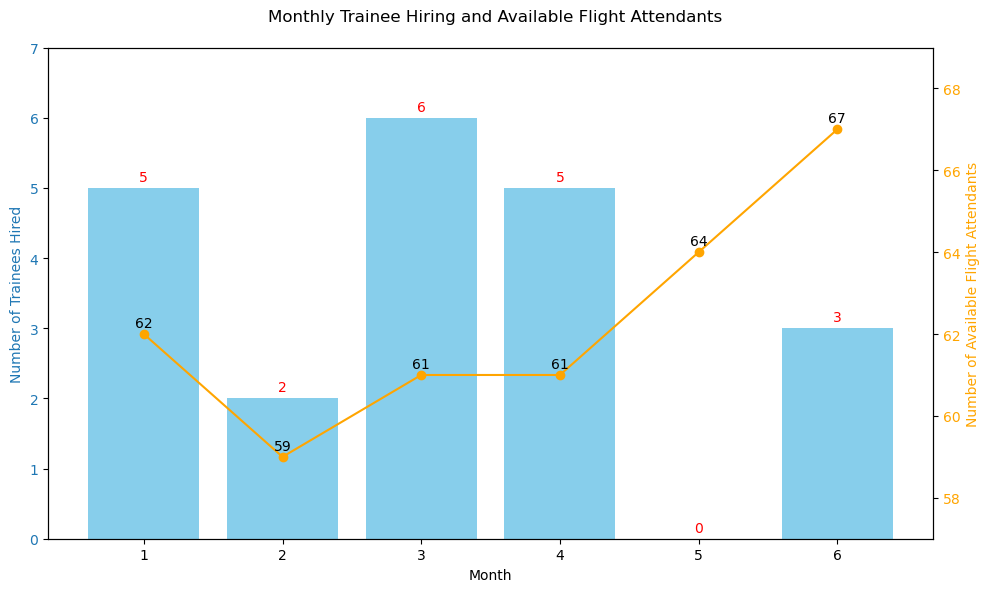

In [41]:
if model_2.status == COPT.OPTIMAL:
    print(f'Optimal total cost: {model_2.objVal:0f}')
    print('\nMonthly trainee hiring plan and available flight attendants:')

    months = list(range(1,7))

    trainees = [int(y[t].x) for t in months]
    trainers = [int(x[t].x) for t in months]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart: trainees (left axis)
    ax1.bar(months, trainees, color='skyblue')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Number of Trainees Hired', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, max(trainees) + 1)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Annotate bar values (trainees)
    for x_pos, val in zip(months, trainees):
        ax1.annotate(
            f'{val}',
            xy=(x_pos, val),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            color='red',
            fontsize=10
        )

    # Line chart: flight attendants (right axis)
    ax2 = ax1.twinx()
    ax2.plot(months, trainers, color='orange', marker='o')
    ax2.set_ylabel('Number of Available Flight Attendants', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2_min = min(trainers)
    ax2_max = max(trainers)
    ax2.set_ylim(ax2_min - 2, ax2_max + 2)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotate line points
    for mon, val in zip(months, trainers):
        ax2.annotate(
            f'{val}',
            xy=(mon, val),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            fontsize=10
        )

    fig.suptitle('Monthly Trainee Hiring and Available Flight Attendants')
    plt.tight_layout()
    plt.show()
else:
    print('Optimal solution not found')
